Survivors

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution

def modelo(t,y,p):

    V   = y[0]
    Ap  = y[1]
    ApM = y[2]
    I   = y[3]
    ThN = y[4]
    ThE = y[5]
    TkN = y[6]
    TkE = y[7]
    B   = y[8]
    Ps  = y[9]
    Pl  = y[10]
    Bm  = y[11]
    IgM = y[12]
    IgG = y[13]
    C   = y[14]

    Ap0  = p['Ap0']
    ThN0 = p['ThN0']
    TkN0 = p['TkN0']
    B0   = p['B0']

    dVdt   = p['pi_v']*V - p['kv1']*V*IgG - p['kv1']*V*IgM - p['kv2']*V*TkE - p['kv3']*V*ApM
    dApdt  = p['alpha_ap']*(C + 1.0)*(Ap0 - Ap) - p['beta_ap']*Ap*((p['cap1']*V)/(p['cap2'] + V))
    dApMdt = p['beta_ap']*Ap*((p['cap1']*V)/(p['cap2'] + V)) - p['beta_apm']*ApM*V - p['gama_apm']*ApM 
    dIdt   = p['beta_apm']*ApM*V + p['beta_tke']*TkE*V - p['gama_apm']*I 
    dThNdt = p['alpha_th']*(ThN0 - ThN) - p['beta_th']*ApM*ThN
    dThEdt = p['beta_th']*ApM*ThN + p['pi_th']*ApM*ThE - p['delta_th']*ThE 
    dTkNdt = p['alpha_tk']*(C + 1)*(TkN0 - TkN) - p['beta_tk']*(C + 1)*ApM*TkN
    dTkEdt = p['beta_tk']*(C + 1)*ApM*TkN + p['pi_tk']*ApM*TkE - p['beta_tke']*TkE*V - p['delta_tk']*TkE
    dBdt   = p['alpha_b']*(B0 - B) + p['pi_b1']*V*B + p['pi_b2']*ThE*B - p['beta_ps']*ApM*B - p['beta_pl']*ThE*B - p['beta_bm']*ThE*B
    dPsdt  = p['beta_ps']*ApM*B - p['delta_ps']*Ps
    dPldt  = p['beta_pl']*ThE*B - p['delta_pl']*Pl + p['delta_bm']*Bm
    dBmdt  = p['beta_bm']*ThE*B + p['pi_bm1']*Bm*(1.0 - (Bm/p['pi_bm2'])) - p['delta_bm']*Bm
    dIgMdt = p['pi_ps']*Ps - p['delta_am']*IgM
    dIgGdt = p['pi_pl']*Pl - p['delta_ag']*IgG
    dCdt   = p['pi_capm']*ApM + p['pi_ci']*I + p['pi_ctke']*TkE - p['gama_c']*C

    dydt = [dVdt, dApdt, dApMdt, dIdt, dThNdt, 
            dThEdt, dTkNdt, dTkEdt, dBdt, dPsdt,
            dPldt, dBmdt,  dIgMdt,  dIgGdt, dCdt]

    return dydt

# DADOS EXPERIMENTAIS
dataset_viremia = pd.read_csv(r"C:\Users\karla\OneDrive\Documentos\UFJF\Modelagem Fisiologica\covid19_model\data\Viral_load.csv", sep = ',')
dataset_il6 = pd.read_csv(r"C:\Users\karla\OneDrive\Documentos\UFJF\Modelagem Fisiologica\covid19_model\data\dataset_il6_survivor.csv", sep = ',')
dataset_IgG = pd.read_csv(r"C:\Users\karla\OneDrive\Documentos\UFJF\Modelagem Fisiologica\covid19_model\data\IgG_data.csv", sep = ',')
dataset_IgM = pd.read_csv(r"C:\Users\karla\OneDrive\Documentos\UFJF\Modelagem Fisiologica\covid19_model\data\IgM_data.csv",sep = ',')

# Pega os valores de x e y das linhas do .csv referentes às medias
data_v = (dataset_viremia[dataset_viremia.type == 'mean']['x'].values, 
          np.log10(dataset_viremia[dataset_viremia.type == 'mean']['y'].values + 1))
data_c = (dataset_il6[dataset_il6.type == 'mean']['x'].values, 
          dataset_il6[dataset_il6.type == 'mean']['y'].values)
data_g = (dataset_IgG[dataset_IgG.type == 'mean']['x'].values, 
          np.log2(dataset_IgG[dataset_IgG.type == 'mean']['y'].values + 1))
data_m = (dataset_IgM[dataset_IgM.type == 'mean']['x'].values, 
          np.log2(dataset_IgM[dataset_IgM.type == 'mean']['y'].values + 1))


# Parâmetros para otimizar (dicionário pars)
pars = {}
pars['pi_v']     = 1.47
pars['kv1']      = 9.82e-3
pars['kv2']      = 6.10e-5
pars['kv3']      = 6.45e-2
pars['alpha_ap'] = 1.0
pars['beta_ap']  = 1.79e-1
pars['cap1']     = 8.0
pars['cap2']     = 8.08e6
pars['gama_apm'] = 4.0e-2
pars['beta_apm'] = 1.33e-2
pars['beta_tke'] = 3.5e-6
pars['alpha_th'] = 2.17e-4
pars['beta_th']  = 1.8e-5
pars['pi_th']    = 1.0e-8
pars['delta_th']  = 3.0e-1
pars['alpha_tk'] = 1.0
pars['beta_tk']  = 1.43e-5
pars['pi_tk']    = 1.0e-8
#pars['delta_tk']  = 3.0e-1
pars['delta_tk']  = 3.0e-2
#pars['alpha_b']  = 3.58e2
pars['alpha_b']  = 3.578236584
pars['pi_b1']    = 8.98e-5
pars['pi_b2']    = 1.27e-8
pars['beta_ps']  = 6.0e-6
pars['beta_pl']  = 5.0e-6
pars['beta_bm']  = 1.0e-6
pars['delta_ps']  = 2.5
pars['delta_pl']  = 3.5e-1
pars['delta_bm']  = 9.75e-4
pars['pi_bm1']   = 1.0e-5
pars['pi_bm2']   = 2.5e3
pars['pi_ps']    = 8.7e-2
pars['pi_pl']    = 1.0e-3
pars['delta_am']  = 7.0e-2
pars['delta_ag']  = 7.0e-2
pars['pi_capm']  = 3.28e2
pars['pi_ci']    = 6.44e-3
pars['pi_ctke']  = 1.78e-2
pars['gama_c']   = 7.04e2


# Condições Iniciais 
V0   = 61.0  # copies/mL
Ap0  = 1.0e6 # cells/mL
ApM0 = 0.0   # cells/mL
I0   = 0.0   # cells/mL
ThN0 = 1.0e6 # cells/mL
ThE0 = 0.0   # cells/mL
TkN0 = 5.0e5 # cells/mL
TkE0 = 0.0   # cells/mL
B0   = 2.5e5 # cells/mL
Ps0  = 0.0   # cells/mL
Pl0  = 0.0   # cells/mL
Bm0  = 0.0   # cells/mL
IgM0 = 0.0   # S/CO
IgG0 = 0.0   # S/CO
C0   = 0.0   # pg/mL

y0 = [V0, Ap0, ApM0, I0, ThN0, ThE0, TkN0, TkE0, B0, Ps0, 
        Pl0, Bm0, IgM0, IgG0, C0]
    
keys_pars = list(pars.keys())
values_pars = list(pars.values())

# Espaço de Busca
bounds = [(val * 0.5, val * 1.5) for val in values_pars]

# Tempo de simulação
tf = 35.0 #dias
dt = 0.01
N = int(tf/dt)
t = np.linspace(0,tf,N)

# FUNÇÃO OBJETIVO
def modelo_objetivo(params):
    p = pars.copy()

    for i, key in enumerate(keys_pars):
        p[key] = params[i]

    # Condições iniciais fixas
    p['Ap0'] = Ap0
    p['ThN0'] = ThN0
    p['TkN0'] = TkN0
    p['B0'] = B0

    sol = solve_ivp(modelo, [0, tf], y0, args = (p,), method = 'Radau', t_eval = t)

    # Função auxiliar para calcular o erro
    def calcula_erro(dados_exp, i, log_func):
        t_exp, y_exp = dados_exp
        y_sim = sol.y[i]

        # Interpolação para alinhar os tempos da simulação com os dados
        y_sim_interp = np.interp(t_exp, sol.t, y_sim)
        
        # Aplica transformação logarítmica para bater com os dados
        if log_func == 'log10':
            y_sim_interp = np.log10(np.maximum(y_sim_interp, 1e-6))
        elif log_func == 'log2':
            y_sim_interp = np.log2(np.maximum(y_sim_interp, 1e-6))

        residuo = y_exp - y_sim_interp
        # Erro relativo
        return np.linalg.norm(residuo, 2)/ np.linalg.norm(y_exp, 2)
    
    erro_viremia = calcula_erro(data_v, 0, 'log10')
    erro_citocina = calcula_erro(data_c, 14, None)
    erro_IgM = calcula_erro(data_m, 12, 'log2')
    erro_IgG = calcula_erro(data_g, 13, 'log2')
    erro_total = erro_viremia + erro_citocina + erro_IgM + erro_IgG

    return erro_total

def model_adj(params):
    return modelo_objetivo(params)

# EVOLUÇÃO DIFERENCIAL
result = differential_evolution(model_adj, bounds, strategy='best1bin', 
                                 popsize=3, tol=0.01, disp=True)


# Melhores parâmetros
p_otimo = pars.copy()
for i, key in enumerate(keys_pars):
    p_otimo[key] = result.x[i]
p_otimo.update({'Ap0': Ap0, 'ThN0': ThN0, 'TkN0': TkN0, 'B0': B0})

sol_final = solve_ivp(modelo, [0, tf], y0, args=(p_otimo,), method='Radau', t_eval=t)

# Gráficos
plt.plot(sol_final.t, np.log10(sol_final.y[0] + 1), color='red')
plt.title("Vírus")
plt.xlabel("t (dias)")
plt.ylabel("V")
plt.grid()


x = dataset_viremia[dataset_viremia.type == 'mean']['x'] + 5
y = np.log10(dataset_viremia[dataset_viremia.type == 'mean']['y'] + 1)

dataset_viremia_up = np.log10(dataset_viremia[dataset_viremia.type == 'up']['y'] + 1)
dataset_viremia_down = np.log10(dataset_viremia[dataset_viremia.type == 'down']['y'] + 1)
dataset_viremia_mean = np.log10(dataset_viremia[dataset_viremia.type == 'mean']['y'] + 1)

y_error = [dataset_viremia_mean.to_numpy() - dataset_viremia_down.to_numpy(), dataset_viremia_up.to_numpy() - dataset_viremia_mean.to_numpy()]

plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='red', capsize=4, elinewidth=1)

plt.show()

plt.plot(sol_final.t, sol_final.y[14], color='blue')
plt.title("Citocinas")
plt.xlabel("t (dias)")
plt.ylabel("C")
plt.grid()
    
x = dataset_il6[dataset_il6.type == 'mean']['x']
y = dataset_il6[dataset_il6.type == 'mean']['y']
dataset_il6_up = dataset_il6[dataset_il6.type == 'up']['y']
dataset_il6_down = dataset_il6[dataset_il6.type == 'down']['y']
dataset_il6_mean = dataset_il6[dataset_il6.type == 'mean']['y']

y_error = [dataset_il6_mean.to_numpy() - dataset_il6_down.to_numpy(), dataset_il6_up.to_numpy() - dataset_il6_mean.to_numpy()]
plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='blue', capsize=4, elinewidth=1)
plt.show()


plt.plot(sol_final.t, np.log2(sol_final.y[13] + 1), color='brown')
plt.title("Anticorpos IgG")
plt.xlabel("t (dias)")
plt.ylabel("$I_{gG}$")
plt.grid()
x = dataset_IgG[dataset_IgG.type == 'mean']['x']
y = np.log2(dataset_IgG[dataset_IgG.type == 'mean']['y'] + 1)

dataset_IgG_up = np.log2(dataset_IgG[dataset_IgG.type == 'up']['y'] + 1)
dataset_IgG_down = np.log2(dataset_IgG[dataset_IgG.type == 'down']['y'] + 1)
dataset_IgG_mean = np.log2(dataset_IgG[dataset_IgG.type == 'mean']['y'] + 1)

y_error = [dataset_IgG_mean.to_numpy() - dataset_IgG_down.to_numpy(), dataset_IgG_up.to_numpy() - dataset_IgG_mean.to_numpy()]
plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='brown', capsize=4, elinewidth=1)

plt.show()
plt.plot(sol_final.t, np.log2(sol_final.y[12] + 1), color='orange')
plt.title("Anticorpos IgM")
plt.xlabel("t (dias)")
plt.ylabel("$I_{gM}$")
plt.grid()

x = dataset_IgM[dataset_IgM.type == 'mean']['x']
y = np.log2(dataset_IgM[dataset_IgM.type == 'mean']['y'] + 1)

dataset_IgM_up = np.log2(dataset_IgM[dataset_IgM.type == 'up']['y'] + 1)
dataset_IgM_down = np.log2(dataset_IgM[dataset_IgM.type == 'down']['y'] + 1)
dataset_IgM_mean = np.log2(dataset_IgM[dataset_IgM.type == 'mean']['y'] + 1)
y_error = [dataset_IgM_mean.to_numpy() - dataset_IgM_down.to_numpy(), dataset_IgM_up.to_numpy() - dataset_IgM_mean.to_numpy()]

plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='orange', capsize=4, elinewidth=1)

plt.show()



differential_evolution step 1: f(x)= 0.7705614536986869
differential_evolution step 2: f(x)= 0.7705614536986869


KeyboardInterrupt: 

Non-Survivors

TypeError: read_csv() takes 1 positional argument but 2 were given

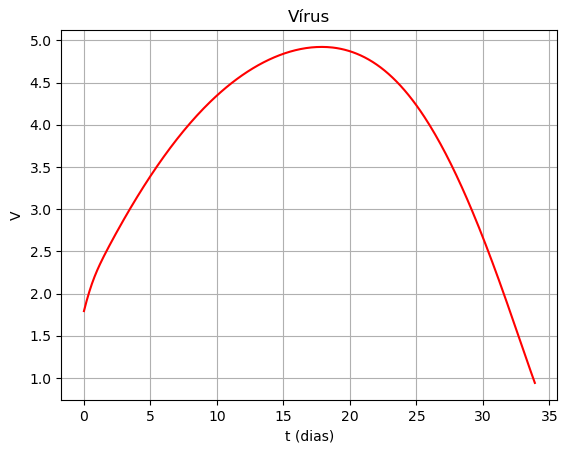

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

def modelo(t, y, pi_v, k_v1, k_v2, k_v3, alfa_ap, beta_ap, c_ap1, c_ap2, delta_apm, beta_apm, beta_tke, alfa_th, beta_th, pi_th, delta_th, alfa_tk, beta_tk, pi_tk, delta_tk, alfa_b, pi_b1, pi_b2, beta_ps, beta_pl, beta_bm, delta_ps, delta_pl, gamma_bm, pi_bm1, pi_bm2, pi_ps, pi_pl, delta_am, delta_ag, pi_c_apm, pi_c_i, pi_c_tke, delta_c, Ap0, Thn0, Tkn0, B0):
  V, Ap, Apm, I, Thn, The, Tkn, Tke, B, Ps, Pl, Bm, IgM, IgG, C = y[0], y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14]

  dVdt = pi_v * V - k_v1 * V * IgG - k_v1 * V * IgM - k_v2 * V * Tke - k_v3 * V * Apm # vírus

  dApdt = alfa_ap * (C + 1) * (Ap0 - Ap) - beta_ap * Ap * ((c_ap1 * V) / (c_ap2 + V))  # APCs imaturas

  dApmdt = beta_ap * Ap * ((c_ap1 * V) / (c_ap2 + V)) - beta_apm * Apm * V - delta_apm * Apm  # APCs maduras

  dIdt = beta_apm * Apm * V + beta_tke * Tke * V - delta_apm * I  # células infectadas

  dThndt = alfa_th * (Thn0 - Thn) - beta_th * Apm * Thn  # células T CD4+ imaturas

  dThedt = beta_th * Apm * Thn + pi_th * Apm * The - delta_th * The # células T CD4+ maduras

  dTkndt = alfa_tk * (C + 1) * (Tkn0 - Tkn) - beta_tk * (C + 1) * Apm * Tkn # células T CD8+ imaturas

  dTkedt = beta_tk * (C + 1) * Apm * Tkn + pi_tk * Apm * Tke - beta_tke * Tke * V - delta_tk * Tke # células T CD8+ maduras

  dBdt = alfa_b * (B0 - B) + pi_b1 * V * B + pi_b2 * The * B - beta_ps * Apm * B - beta_pl * The * B - beta_bm * The * B # células B

  dPsdt = beta_ps * Apm * B - delta_ps * Ps # plasmócitos de vida curta

  dPldt = beta_pl * The * B - delta_pl * Pl + gamma_bm * Bm # plasmócitos de vida longa

  dBmdt = beta_bm * The * B + pi_bm1 * Bm * (1 - (Bm / pi_bm2)) - gamma_bm * Bm # células B de memória

  dIgMdt = pi_ps * Ps - delta_am * IgM # anticorpos IgM

  dIgGdt = pi_pl * Pl - delta_ag * IgG # anticorpos IgG

  dCdt = pi_c_apm * Apm + pi_c_i * I + pi_c_tke * Tke - delta_c * C # citocinas
  
  return [ dVdt, dApdt, dApmdt, dIdt, dThndt, dThedt, dTkndt, dTkedt, dBdt, dPsdt, dPldt, dBmdt, dIgMdt, dIgGdt, dCdt ]


# intervalo de tempo
t0 = 0.0
tf = 34.0
t = np.arange(t0, tf, 0.1)
t_span = (t0, tf)

# condições iniciais
V0 = 61.0
Ap0 = 10**(6)
Apm0 = 0.0
I0 = 0.0
Thn0 = 10**(6)
The0 = 0.0
Tkn0 = 5.0 * 10**(5)
Tke0 = 0.0
B0 = 2.5 * 10**(5)
Ps0 = 0.0
Pl0 = 0.0
Bm0 = 0.0
IgM0 = 0.0
IgG0 = 0.0
C0 = 0.0

# valores dos parâmetros
#pi_v = 1.47 * 10**(0)
pi_v = 1.4742055035646986
k_v1 = 9.82 * 10**(-3)
k_v2 = 6.10 * 10**(-5)
k_v3 = 6.45 * 10**(-2)
alfa_ap = 1.0 * 10**(0)
beta_ap = 1.79 * 10**(-1)
c_ap1 = 8.0 * 10**(0)
c_ap2 = 8.08 * 10**(6)
delta_apm = 4.0 * 10**(-2)
beta_apm = 1.51 * 10**(-2)
beta_tke = 1.0 * 10**(-6)
alfa_th = 2.17 * 10**(-4)
beta_th = 1.8 * 10**(-5)
pi_th = 1.0 * 10**(-8)
delta_th = 3.0 * 10**(-1)
alfa_tk = 1.0 * 10**(0)
beta_tk = 1.43 * 10**(-5)
pi_tk = 1.0 * 10**(-8)
delta_tk = 3.0e-2
#alfa_b = 3.578236584
alfa_b = 3.578236584371140339e+02
pi_b1 = 8.98 * 10**(-5)
pi_b2 = 1.27 * 10**(-8)
beta_ps = 6.0 * 10**(-6)
beta_pl = 5.0 * 10**(-6)
beta_bm = 1.0 * 10**(-6)
delta_ps = 2.5 * 10**(0)
delta_pl = 3.5 * 10**(-1)
gamma_bm = 9.75 * 10**(-4)
pi_bm1 = 1.0 * 10**(-5)
pi_bm2 = 2.5 * 10**(3)
pi_ps = 8.7 * 10**(-2)
pi_pl = 1.0 * 10**(-3) 
delta_am = 7.0 * 10**(-2) 
delta_ag = 7.0 * 10**(-2)
pi_c_apm = 3.28 * 10**(2)
pi_c_i = 9.96 * 10**(-2)
pi_c_tke = 1.78 * 10**(-2)
delta_c = 7.04 * 10**(2)

y0 =  [V0, Ap0, Apm0, I0, Thn0, The0, Tkn0, Tke0, B0, Ps0, Pl0, Bm0, IgM0, IgG0, C0]
mmargs = (pi_v, k_v1, k_v2, k_v3, alfa_ap, beta_ap, c_ap1, c_ap2, delta_apm, beta_apm, beta_tke, alfa_th, beta_th, pi_th, delta_th, alfa_tk, beta_tk, pi_tk, delta_tk, alfa_b, pi_b1, pi_b2, beta_ps, beta_pl, beta_bm, delta_ps, delta_pl, gamma_bm, pi_bm1, pi_bm2, pi_ps, pi_pl, delta_am, delta_ag, pi_c_apm, pi_c_i, pi_c_tke, delta_c, Ap0, Thn0, Tkn0, B0)

sol = solve_ivp(modelo, t_span, y0, args=(mmargs), method='Radau', t_eval=t)

# gráficos

plt.plot(sol.t, np.log10(sol.y[0] + 1), color='red')
plt.title("Vírus")
plt.xlabel("t (dias)")
plt.ylabel("V")
plt.grid()

dataset_viremia = pd.read_csv("https://raw.githubusercontent.com/ruyfreis/covid19_model/main/data/Viral_load.csv",',')

x = dataset_viremia[dataset_viremia.type == 'mean']['x'] + 5
y = np.log10(dataset_viremia[dataset_viremia.type == 'mean']['y'] + 1)

dataset_viremia_up = np.log10(dataset_viremia[dataset_viremia.type == 'up']['y'] + 1)
dataset_viremia_down = np.log10(dataset_viremia[dataset_viremia.type == 'down']['y'] + 1)
dataset_viremia_mean = np.log10(dataset_viremia[dataset_viremia.type == 'mean']['y'] + 1)

y_error = [dataset_viremia_mean.to_numpy() - dataset_viremia_down.to_numpy(), dataset_viremia_up.to_numpy() - dataset_viremia_mean.to_numpy()]

plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='red', capsize=4, elinewidth=1)

plt.show()


plt.plot(sol.t, sol.y[14], color='blue')
plt.title("Citocinas")
plt.xlabel("t (dias)")
plt.ylabel("C")
plt.grid()

dataset_il6 = pd.read_csv("https://raw.githubusercontent.com/ruyfreis/covid19_model/main/data/dataset_il6_non_survivor.csv",',')

x = dataset_il6[dataset_il6.type == 'mean']['x']
y = dataset_il6[dataset_il6.type == 'mean']['y']

dataset_il6_up = dataset_il6[dataset_il6.type == 'up']['y']
dataset_il6_down = dataset_il6[dataset_il6.type == 'down']['y']
dataset_il6_mean = dataset_il6[dataset_il6.type == 'mean']['y']

y_error = [dataset_il6_mean.to_numpy() - dataset_il6_down.to_numpy(), dataset_il6_up.to_numpy() - dataset_il6_mean.to_numpy()]

plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='blue', capsize=4, elinewidth=1)

plt.show()


plt.plot(sol.t, np.log2(sol.y[13] + 1), color='brown')
plt.title("Anticorpos IgG")
plt.xlabel("t (dias)")
plt.ylabel("$I_{gG}$")
plt.grid()

dataset_IgG = pd.read_csv("https://raw.githubusercontent.com/ruyfreis/covid19_model/main/data/IgG_data.csv",',')

x = dataset_IgG[dataset_IgG.type == 'mean']['x']
y = np.log2(dataset_IgG[dataset_IgG.type == 'mean']['y'] + 1)

dataset_IgG_up = np.log2(dataset_IgG[dataset_IgG.type == 'up']['y'] + 1)
dataset_IgG_down = np.log2(dataset_IgG[dataset_IgG.type == 'down']['y'] + 1)
dataset_IgG_mean = np.log2(dataset_IgG[dataset_IgG.type == 'mean']['y'] + 1)

y_error = [dataset_IgG_mean.to_numpy() - dataset_IgG_down.to_numpy(), dataset_IgG_up.to_numpy() - dataset_IgG_mean.to_numpy()]

plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='brown', capsize=4, elinewidth=1)

plt.show()

plt.plot(sol.t, np.log2(sol.y[12] + 1), color='orange')
plt.title("Anticorpos IgM")
plt.xlabel("t (dias)")
plt.ylabel("$I_{gM}$")
plt.grid()

dataset_IgM = pd.read_csv("https://raw.githubusercontent.com/ruyfreis/covid19_model/main/data/IgM_data.csv",',')

x = dataset_IgM[dataset_IgM.type == 'mean']['x']
y = np.log2(dataset_IgM[dataset_IgM.type == 'mean']['y'] + 1)

dataset_IgM_up = np.log2(dataset_IgM[dataset_IgM.type == 'up']['y'] + 1)
dataset_IgM_down = np.log2(dataset_IgM[dataset_IgM.type == 'down']['y'] + 1)
dataset_IgM_mean = np.log2(dataset_IgM[dataset_IgM.type == 'mean']['y'] + 1)

y_error = [dataset_IgM_mean.to_numpy() - dataset_IgM_down.to_numpy(), dataset_IgM_up.to_numpy() - dataset_IgM_mean.to_numpy()]

plt.errorbar(x,y, yerr = y_error, linestyle='None', label='Data', fmt='o', color='orange', capsize=4, elinewidth=1)

plt.show()

